In [52]:
!pip install ultralytics opencv-python matplotlib

Saving 1009.png to 1009.png


(np.float64(-0.5), np.float64(1079.5), np.float64(719.5), np.float64(-0.5))

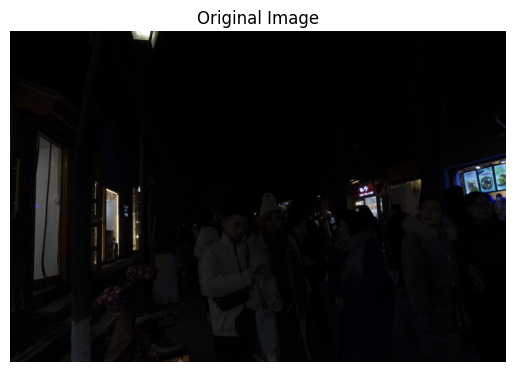

In [59]:
from google.colab import files
import cv2
import numpy as np
from matplotlib import pyplot as plt

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(1079.5), np.float64(719.5), np.float64(-0.5))

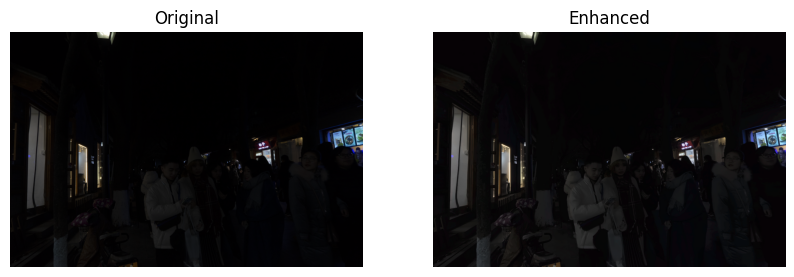

In [60]:
def enhance(img):
    # Light denoising (preserve edges)
    denoised = cv2.fastNlMeansDenoisingColored(img, None, 3, 3, 7, 21)

    # CLAHE (controlled contrast enhancement)
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8,8))
    l2 = clahe.apply(l)

    return cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2BGR)

enhanced = enhance(image)

# Visualization
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
plt.title("Enhanced")
plt.axis("off")

In [61]:
from ultralytics import YOLO

model = YOLO("yolov8n-face (1).pt")

CONF_THRES = 0.2

In [62]:
def detect(img, conf_thres=0.2):
    results = model(img, conf=conf_thres)

    detections = []
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            detections.append((x1, y1, x2, y2, conf))

    return detections

In [63]:
raw_dets = detect(image, CONF_THRES)
enh_dets = detect(enhanced, CONF_THRES)

def score(dets):
    if len(dets) == 0:
        return 0
    return sum([c for *_, c in dets]) / len(dets)

score_raw = score(raw_dets)
score_enh = score(enh_dets) * 1.05  # slight bias toward enhanced

if score_enh > score_raw:
    best_img = enhanced
    best_dets = enh_dets
    source = "Enhanced"
else:
    best_img = image
    best_dets = raw_dets
    source = "Original"

print(f"Selected Source: {source}")
print(f"Faces detected: {len(best_dets)}")


0: 448x640 8 faces, 153.2ms
Speed: 5.7ms preprocess, 153.2ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 9 faces, 149.2ms
Speed: 4.4ms preprocess, 149.2ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
Selected Source: Enhanced
Faces detected: 9


(np.float64(-0.5), np.float64(1079.5), np.float64(719.5), np.float64(-0.5))

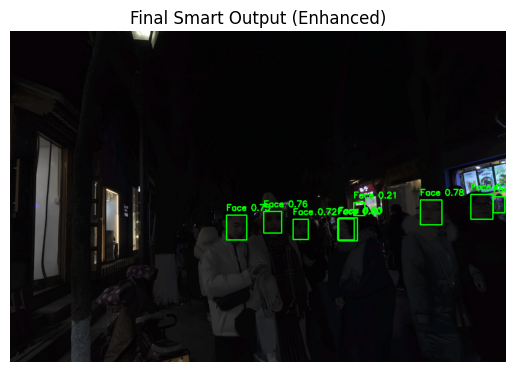

In [64]:
output = best_img.copy()

for (x1, y1, x2, y2, conf) in best_dets:
    cv2.rectangle(output, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(
        output,
        f"Face {conf:.2f}",
        (x1, y1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0,255,0),
        2
    )

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"Final Smart Output ({source})")
plt.axis("off")